## Potrzebne biblioteki

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

dataset = datasets.ImageFolder("trafic_32", transform=transform)
dataloader = data.DataLoader(dataset, batch_size=64, shuffle=True)

## Rozkład próbek w klasach

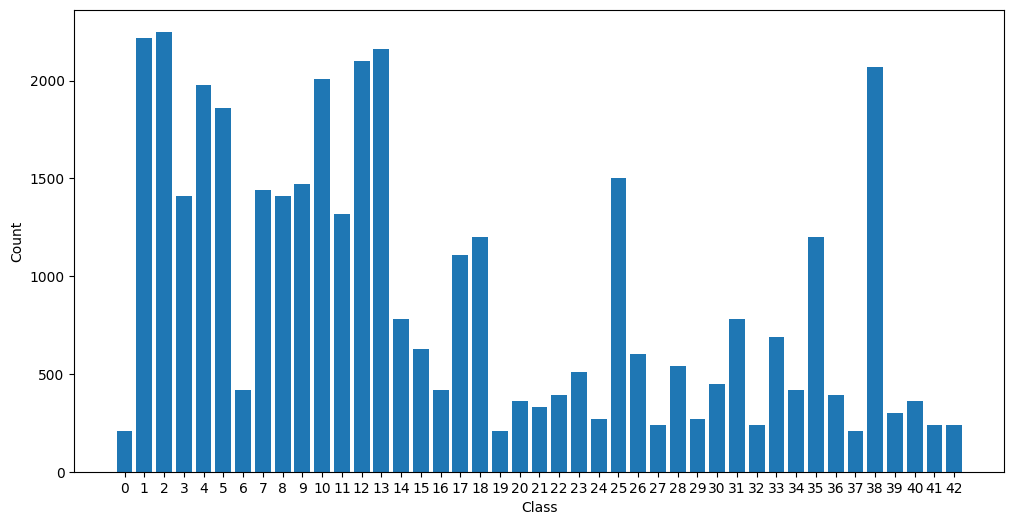

In [4]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()

        self.conv_1 = nn.Conv2d(input_dim, hidden_dim, 4, 2, 1, bias=False)

        self.conv_2 = nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1, bias=False)
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1, bias=False)
        self.bn_3 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_out = nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.act(self.conv_1(x))
        x = self.act(self.bn_2(self.conv_2(x)))
        x = self.act(self.bn_3(self.conv_3(x)))

        x = torch.sigmoid(self.conv_out(x))
        return torch.flatten(x)


class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()

        self.conv_1 = nn.ConvTranspose2d(
            latent_dim, hidden_dim * 4, 4, 1, 0, bias=False
        )
        self.bn_1 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_2 = nn.ConvTranspose2d(
            hidden_dim * 4, hidden_dim * 2, 4, 2, 1, bias=False
        )
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim, 4, 2, 1, bias=False
        )
        self.bn_3 = nn.BatchNorm2d(hidden_dim)

        self.conv_4 = nn.ConvTranspose2d(hidden_dim, output_dim, 4, 2, 1, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.act(self.bn_1(self.conv_1(x)))
        h = self.act(self.bn_2(self.conv_2(h)))
        h = self.act(self.bn_3(self.conv_3(h)))

        x_hat = torch.sigmoid(self.conv_4(h))
        return x_hat

In [ ]:
latent_dim = 128
hidden_dim = 64
channels = 3
num_classes = len(dataset.class_to_idx)

generator = Generator(
    latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=channels
).to(device)

discriminator = Discriminator(input_dim=channels, hidden_dim=hidden_dim).to(device)


generator_optimizer = torch.optim.Adam(
    generator.parameters(), lr=0.0004, betas=(0.5, 0.999)
)
generator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=generator_optimizer, gamma=0.99
)
discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999)
)
discriminator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=discriminator_optimizer, gamma=0.99
)

criterion = nn.BCELoss()

In [ ]:
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

Epoch: 0, discriminator fake error: 0.080, discriminator real acc: 0.922


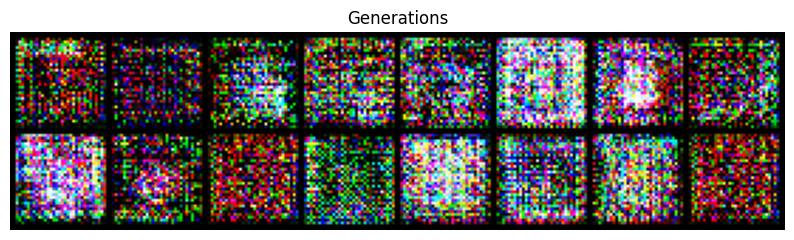

Epoch: 1, discriminator fake error: 0.017, discriminator real acc: 0.983
Epoch: 2, discriminator fake error: 0.010, discriminator real acc: 0.989
Epoch: 3, discriminator fake error: 0.005, discriminator real acc: 0.995
Epoch: 4, discriminator fake error: 0.009, discriminator real acc: 0.991
Epoch: 5, discriminator fake error: 0.015, discriminator real acc: 0.986
Epoch: 6, discriminator fake error: 0.006, discriminator real acc: 0.994
Epoch: 7, discriminator fake error: 0.009, discriminator real acc: 0.991
Epoch: 8, discriminator fake error: 0.003, discriminator real acc: 0.997
Epoch: 9, discriminator fake error: 0.002, discriminator real acc: 0.998
Epoch: 10, discriminator fake error: 0.007, discriminator real acc: 0.993


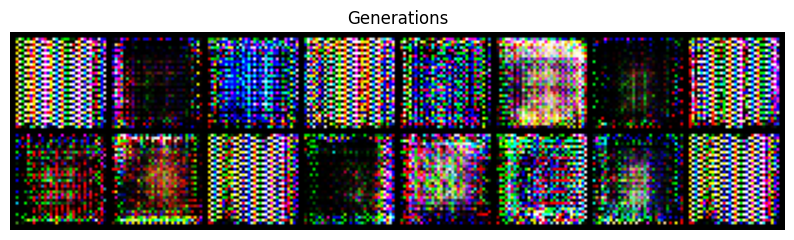

Epoch: 11, discriminator fake error: 0.006, discriminator real acc: 0.994
Epoch: 12, discriminator fake error: 0.004, discriminator real acc: 0.997
Epoch: 13, discriminator fake error: 0.000, discriminator real acc: 1.000
Epoch: 14, discriminator fake error: 0.005, discriminator real acc: 0.995


In [ ]:
G_losses = []
D_losses = []
num_epochs = 100
for epoch in range(num_epochs):
    sum_d_fake_acc = torch.tensor(0.0, device=device)
    sum_d_real_acc = torch.tensor(0.0, device=device)
    sum_g_loss = torch.tensor(0.0, device=device)
    sum_d_loss = torch.tensor(0.0, device=device)

    num_batches = 0

    for i, data in enumerate(dataloader, 0):
        num_batches += 1
        ########################
        # (1) Update D network #
        ########################

        ## Train with all-real batch
        discriminator_optimizer.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(real_images).view(-1)
        error_discriminator_real = criterion(output, label)
        sum_d_real_acc += output.mean().detach()

        ## Train with all-fake batch
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)

        fake_images = generator(noise)
        label_fake = torch.zeros((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images.detach()).view(-1)
        error_discriminator_fake = criterion(output, label_fake)
        sum_d_fake_acc += output.mean().detach()

        error_discriminator = error_discriminator_real + error_discriminator_fake
        sum_d_loss += error_discriminator.detach()

        error_discriminator.backward()

        discriminator_optimizer.step()

        ########################
        # (2) Update G network #
        ########################
        generator_optimizer.zero_grad()
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images).view(-1)
        error_generator = criterion(output, label)
        error_generator.backward()

        generator_optimizer.step()

        sum_g_loss += error_generator.detach()

    avg_d_fake_acc = (sum_d_fake_acc / num_batches).item()
    avg_d_real_acc = (sum_d_real_acc / num_batches).item()
    avg_g_loss = (sum_g_loss / num_batches).item()
    avg_d_loss = (sum_d_loss / num_batches).item()

    G_losses.append(avg_g_loss)
    D_losses.append(avg_d_loss)

    print(
        f"Epoch: {epoch}, discriminator fake error: {avg_d_fake_acc:.3f}, discriminator real acc: {avg_d_real_acc:.3f}"
    )
    generator_scheduler.step()
    discriminator_scheduler.step()
    if epoch % 10 == 0:
        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake)
        grid = grid.permute(1, 2, 0)
        plt.figure(figsize=(10, 10))
        plt.title(f"Generations")
        plt.imshow(grid)
        plt.axis("off")
        plt.show()